In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_airlines = pd.read_csv('dados/airlines.csv')
df_airports = pd.read_csv('dados/airports.csv')
df_flights = pd.read_csv('dados/flights.csv')

print(f"airlines: {df_airlines.shape}")
print(f"airports: {df_airports.shape}")
print(f"flights:  {df_flights.shape}")

C:\Users\william.mendes\AppData\Local\Temp\ipykernel_7100\1943997430.py:3: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv('dados/flights.csv')


airlines: (14, 2)
airports: (322, 7)
flights:  (5819079, 31)


In [4]:
df_airlines.head()

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [5]:
df_airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [6]:
df_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df = df_flights.merge(
    df_airlines, 
    left_on='AIRLINE', 
    right_on='IATA_CODE', 
    how='left', 
    suffixes=('', '_AIRLINE')
).rename(columns={'AIRLINE_AIRLINE': 'AIRLINE_NAME'}).drop(columns=['IATA_CODE'])

In [8]:
df = df.merge(
    df_airports, 
    left_on='ORIGIN_AIRPORT', 
    right_on='IATA_CODE', 
    how='left', 
    suffixes=('', '_ORIGIN')
).drop(columns=['IATA_CODE']).rename(columns={
    'AIRPORT': 'ORIGIN_AIRPORT_NAME',
    'CITY': 'ORIGIN_CITY',
    'STATE': 'ORIGIN_STATE',
    'COUNTRY': 'ORIGIN_COUNTRY',
    'LATITUDE': 'ORIGIN_LATITUDE',
    'LONGITUDE': 'ORIGIN_LONGITUDE'
})

In [9]:
df = df.merge(
    df_airports, 
    left_on='DESTINATION_AIRPORT', 
    right_on='IATA_CODE', 
    how='left', 
    suffixes=('', '_DEST')
).drop(columns=['IATA_CODE']).rename(columns={
    'AIRPORT': 'DEST_AIRPORT_NAME',
    'CITY': 'DEST_CITY',
    'STATE': 'DEST_STATE',
    'COUNTRY': 'DEST_COUNTRY',
    'LATITUDE': 'DEST_LATITUDE',
    'LONGITUDE': 'DEST_LONGITUDE'
})

print(f"Shape final do df: {df.shape}")

Shape final do df: (5819079, 44)


### Visao Geral do Dataset

O dataset contem **5.819.079 voos domesticos** nos Estados Unidos, operados por **14 companhias aereas**, cobrindo **12.377 trajetos unicos** entre aeroportos ao longo do ano de 2015. Apos o merge com as bases de aeroportos e companhias, o dataframe consolidado possui **44 colunas**.

### Quanto tempo tem em média um voo por trajeto?

In [10]:
media_tempo = df['ELAPSED_TIME'].mean()
media_tempo_horas = media_tempo / 60

print(f"Tempo médio geral de um voo: {media_tempo:.0f} minutos ({media_tempo_horas:.2f} horas)")

Tempo médio geral de um voo: 137 minutos (2.28 horas)


In [11]:
trajeto_tempo = (
    df.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])['ELAPSED_TIME']
    .mean()
    .reset_index()
    .sort_values('ELAPSED_TIME', ascending=False)
)

In [12]:
print(f"Total de trajetos únicos: {len(trajeto_tempo)}")

Total de trajetos únicos: 12377


In [13]:
# Top 10 trajetos mais longos  
display(trajeto_tempo.head(10))

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ELAPSED_TIME
9941,JFK,HNL,665.968153
5693,12478,12173,656.500000
1860,12478,12173,651.160000
9248,EWR,HNL,650.464832
5179,11618,12173,648.500000
1330,11618,12173,632.896552
9645,IAD,HNL,615.867470
1632,12264,12173,599.000000
1542,12173,12478,579.280000
145,10397,12173,577.321429


In [14]:
# Top 10 trajetos mais curtos
display(trajeto_tempo.tail(10))

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ELAPSED_TIME
11349,PHX,MHT,NaN
11424,PLN,CIU,NaN
11488,RAP,JMS,NaN
11710,SAV,BQK,NaN
11727,SBN,CVG,NaN
11916,SGF,HYS,NaN
12164,STL,PIA,NaN
12198,SWF,LGA,NaN
12343,TYS,CLL,NaN
12350,TYS,LEX,NaN


### Duracao dos Voos

- **Tempo medio de voo**: 137 minutos (~2h17min)
- **Trajetos mais longos**: Rotas transcontinentais como JFK-HNL (Nova York → Honolulu) com media de ~666 minutos (~11h)
- **Trajetos mais curtos**: Rotas regionais curtas entre cidades proximas
- Alguns trajetos apresentam **valores nulos** em tempo de voo, indicando voos cancelados que nao completaram o percurso

**Insight**: A grande variabilidade na duracao dos voos (de minutos a mais de 11 horas) sugere que a distancia e o tipo de rota sao fatores relevantes para a analise de atrasos, ja que voos mais longos podem ter dinamicas operacionais diferentes.

### Tem atrasos? Qual a média, mínimo e máximo de atraso?

In [15]:
# Considerando atraso = DEPARTURE_DELAY > 0 ou ARRIVAL_DELAY > 0

atrasos_chegada = df[df['ARRIVAL_DELAY'] > 0]['ARRIVAL_DELAY']

In [16]:
total_voos = len(df)
print(f"Total de voos: {total_voos:,}")

Total de voos: 5,819,079


In [17]:
atrasos_partida = df[df['DEPARTURE_DELAY'] > 0]['DEPARTURE_DELAY']
pct_atrasos_partida = len(atrasos_partida) / total_voos * 100

print(f"Voos com atraso na partida:  {len(atrasos_partida):,} ({pct_atrasos_partida:.1f}%)")
print(f"Média de atraso:             {atrasos_partida.mean():.1f} min")
print(f"Mínimo de atraso:            {atrasos_partida.min():.0f} min")
print(f"Máximo de atraso:            {atrasos_partida.max():.0f} min")
print(f"Mediana:                     {atrasos_partida.median():.0f} min")

Voos com atraso na partida:  2,125,618 (36.5%)
Média de atraso:             32.7 min
Mínimo de atraso:            1 min
Máximo de atraso:            1988 min
Mediana:                     14 min


In [18]:
atrasos_chegada = df[df['ARRIVAL_DELAY'] > 0]['ARRIVAL_DELAY']
pct_atrasos_chegada = len(atrasos_chegada) / total_voos * 100

print(f"Voos com atraso na chegada:  {len(atrasos_chegada):,} ({pct_atrasos_chegada:.1f}%)")
print(f"Média de atraso:             {atrasos_chegada.mean():.1f} min")
print(f"Mínimo de atraso:            {atrasos_chegada.min():.0f} min")
print(f"Máximo de atraso:            {atrasos_chegada.max():.0f} min")
print(f"Mediana:                     {atrasos_chegada.median():.0f} min")

Voos com atraso na chegada:  2,086,896 (35.9%)
Média de atraso:             33.1 min
Mínimo de atraso:            1 min
Máximo de atraso:            1971 min
Mediana:                     15 min


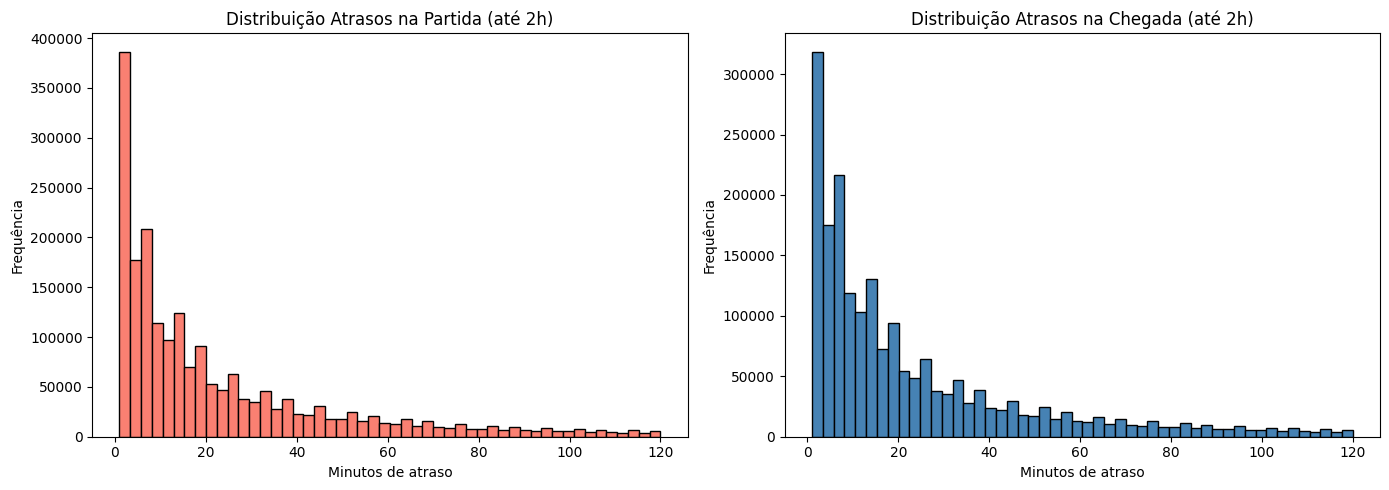

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(atrasos_partida[atrasos_partida <= 120], bins=50, color='salmon', edgecolor='black')
axes[0].set_title('Distribuição Atrasos na Partida (até 2h)')
axes[0].set_xlabel('Minutos de atraso')
axes[0].set_ylabel('Frequência')

axes[1].hist(atrasos_chegada[atrasos_chegada <= 120], bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Distribuição Atrasos na Chegada (até 2h)')
axes[1].set_xlabel('Minutos de atraso')
axes[1].set_ylabel('Frequência')
plt.tight_layout()
plt.show()

### Panorama de Atrasos

#### Atrasos na Partida
| Metrica | Valor |
|---------|-------|
| Voos com atraso | 2.125.618 (36,5%) |
| Media de atraso | 32,7 min |
| Mediana | 14 min |
| Maximo | 1.988 min (~33h) |

#### Atrasos na Chegada
| Metrica | Valor |
|---------|-------|
| Voos com atraso | 2.086.896 (35,9%) |
| Media de atraso | 33,1 min |
| Mediana | 15 min |
| Maximo | 1.971 min (~33h) |

**Insight**: Mais de **1 em cada 3 voos** sofre algum tipo de atraso. A mediana (14-15 min) e significativamente menor que a media (32-33 min), indicando que a distribuicao e **fortemente assimetrica a direita** — a maioria dos atrasos e moderada, mas existe uma cauda longa de atrasos extremos que inflacionam a media. Casos extremos de ate ~33 horas representam situacoes excepcionais (provavelmente cancelamentos reclassificados ou problemas graves).

### Tem adiantamento? Média, mínimo e máximo de adiantamento

In [20]:
adiant_partida = df[df['DEPARTURE_DELAY'] < 0]['DEPARTURE_DELAY'].abs()

print(f"Voos adiantados na partida: {len(adiant_partida):,} ({len(adiant_partida)/total_voos*100:.1f}%)")
print(f"Média de adiantamento:      {adiant_partida.mean():.1f} min")
print(f"Mínimo de adiantamento:     {adiant_partida.min():.0f} min")
print(f"Máximo de adiantamento:     {adiant_partida.max():.0f} min")

Voos adiantados na partida: 3,277,948 (56.3%)
Média de adiantamento:      4.8 min
Mínimo de adiantamento:     1 min
Máximo de adiantamento:     82 min


In [21]:
adiant_chegada = df[df['ARRIVAL_DELAY'] < 0]['ARRIVAL_DELAY'].abs()

print(f"Voos adiantados na chegada: {len(adiant_chegada):,} ({len(adiant_chegada)/total_voos*100:.1f}%)")
print(f"Média de adiantamento:      {adiant_chegada.mean():.1f} min")
print(f"Mínimo de adiantamento:     {adiant_chegada.min():.0f} min")
print(f"Máximo de adiantamento:     {adiant_chegada.max():.0f} min")

Voos adiantados na chegada: 3,500,899 (60.2%)
Média de adiantamento:      12.5 min
Mínimo de adiantamento:     1 min
Máximo de adiantamento:     87 min


In [22]:
pontualidade = pd.DataFrame({
    'Status': ['Adiantado', 'No horário', 'Atrasado'],
    'Partida': [
        len(df[df['DEPARTURE_DELAY'] < 0]),
        len(df[df['DEPARTURE_DELAY'] == 0]),
        len(df[df['DEPARTURE_DELAY'] > 0])
    ],
    'Chegada': [
        len(df[df['ARRIVAL_DELAY'] < 0]),
        len(df[df['ARRIVAL_DELAY'] == 0]),
        len(df[df['ARRIVAL_DELAY'] > 0])
    ]
})

totais = pontualidade[['Partida', 'Chegada']].sum()

pontualidade['Partida_%'] = (pontualidade['Partida'] / totais['Partida'] * 100).round(2)
pontualidade['Chegada_%'] = (pontualidade['Chegada'] / totais['Chegada'] * 100).round(2)

display(pontualidade)

,Status,Partida,Chegada,Partida_%,Chegada_%
0,Adiantado,3277948,3500899,57.18,61.27
1,No horário,329360,126213,5.75,2.21
2,Atrasado,2125618,2086896,37.08,36.52


### Pontualidade e Adiantamentos observados

#### Distribuicao Geral de Pontualidade
| Status | Partida (%) | Chegada (%) |
|--------|-------------|-------------|
| Adiantado | 57,18% | 61,27% |
| No horario | 5,75% | 2,21% |
| Atrasado | 37,08% | 36,52% |

#### Adiantamentos
- **Partida**: 56,3% dos voos saem adiantados (media de 4,8 min de adiantamento)
- **Chegada**: 60,2% dos voos chegam adiantados (media de 12,5 min de adiantamento)

**Insight**: A maioria dos voos opera **adiantada**, especialmente na chegada. Isso sugere que as companhias utilizam **padding** (folga) nos horarios programados — uma pratica comum da industria para melhorar metricas de pontualidade. O gap entre adiantamento medio na partida (4,8 min) e na chegada (12,5 min) indica que os voos frequentemente recuperam tempo no ar.


### Os aviões demoram mais pra sair ou pra chegar?

In [23]:
comparacao = pd.DataFrame({
    'Métrica': ['Média (min)', 'Mediana (min)', 'Desvio Padrão', '% voos atrasados'],
    'Atraso Partida': [
        df['DEPARTURE_DELAY'].mean(),
        df['DEPARTURE_DELAY'].median(),
        df['DEPARTURE_DELAY'].std(),
        (df['DEPARTURE_DELAY'] > 0).mean() * 100
    ],
    'Atraso Chegada': [
        df['ARRIVAL_DELAY'].mean(),
        df['ARRIVAL_DELAY'].median(),
        df['ARRIVAL_DELAY'].std(),
        (df['ARRIVAL_DELAY'] > 0).mean() * 100
    ]
}).round(2)

display(comparacao)

,Métrica,Atraso Partida,Atraso Chegada
0,Média (min),9.37,4.41
1,Mediana (min),-2.00,-5.00
2,Desvio Padrão,37.08,39.27
3,% voos atrasados,36.53,35.86


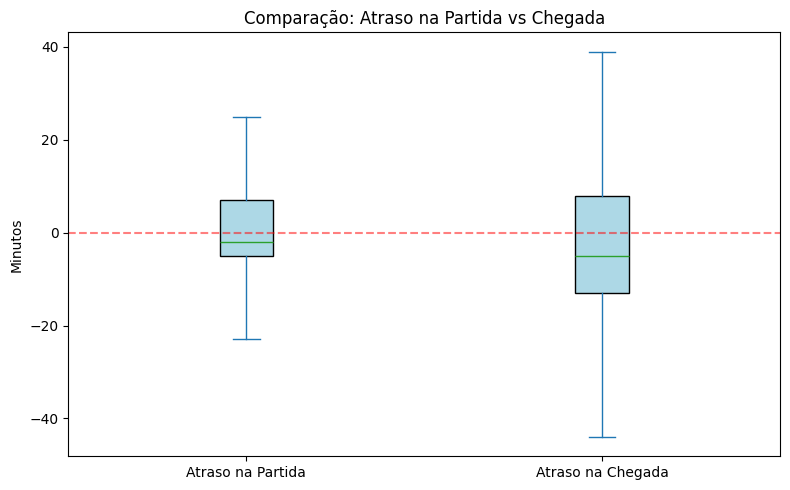

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
delays = pd.DataFrame({
    'Atraso na Partida': df['DEPARTURE_DELAY'].dropna(),
    'Atraso na Chegada': df['ARRIVAL_DELAY'].dropna()
})
delays.plot.box(ax=ax, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
ax.set_ylabel('Minutos')
ax.set_title('Comparação: Atraso na Partida vs Chegada')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Atraso observado

| Metrica | Partida | Chegada |
|---------|---------|---------|
| Media geral (min) | 9,37 | 4,41 |
| Mediana (min) | -2,00 | -5,00 |
| Desvio padrao | 37,08 | 39,27 |
| % atrasados | 36,53% | 35,86% |

**Insight**: O **atraso na partida** e em media mais que o dobro do atraso na chegada (9,37 vs 4,41 min). Isso confirma que as aeronaves **recuperam parte do atraso durante o voo** — possivelmente voando mais rapido ou por conta do padding nos horarios programados. A mediana negativa em ambos os casos mostra que o voo tipico é, na verdade, adiantado. O problema de atrasos esta concentrado numa fracao dos voos que puxa a media para cima.

### Qual companhia aérea mais atrasa?

In [25]:
atraso_por_cia = (
    df.groupby('AIRLINE_NAME')
    .agg(
        media_atraso_partida=('DEPARTURE_DELAY', 'mean'),
        media_atraso_chegada=('ARRIVAL_DELAY', 'mean'),
        pct_atrasados=('ARRIVAL_DELAY', lambda x: (x > 0).mean() * 100),
        total_voos=('ARRIVAL_DELAY', 'count')
    )
    .round(2)
    .sort_values('media_atraso_partida', ascending=False)
)

display(atraso_por_cia)

,media_atraso_partida,media_atraso_chegada,pct_atrasados,total_voos
AIRLINE_NAME,,,,
Spirit Air Lines,15.94,14.47,48.46,115193
United Air Lines Inc.,14.44,5.43,36.11,507762
Frontier Airlines Inc.,13.35,12.50,45.39,90090
JetBlue Airways,11.51,6.68,38.19,262042
Southwest Airlines Co.,10.58,4.37,37.31,1242403
American Eagle Airlines Inc.,10.13,6.46,35.13,278791
Virgin America,9.02,4.74,39.06,61248
American Airlines Inc.,8.90,3.45,34.74,712935
Atlantic Southeast Airlines,8.72,6.59,37.28,554752


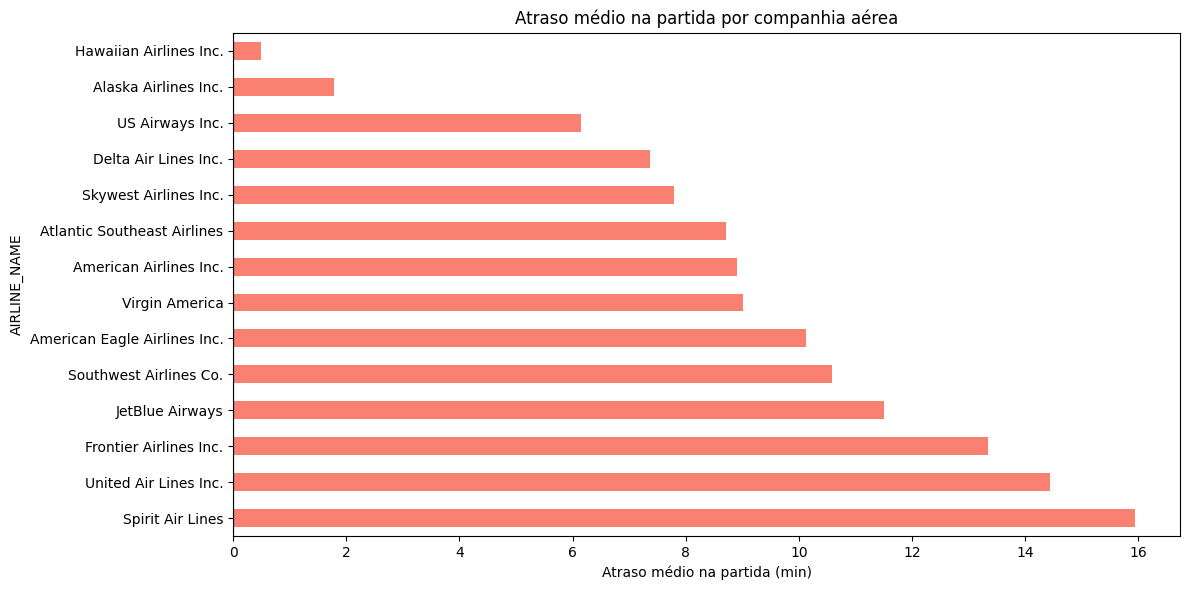

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
atraso_por_cia['media_atraso_partida'].plot(
    kind='barh', ax=ax, color=['salmon' if x > 0 else 'lightgreen' for x in atraso_por_cia['media_atraso_partida']]
)
ax.set_xlabel('Atraso médio na partida (min)')
ax.set_title('Atraso médio na partida por companhia aérea')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

### Companhias Aereas e Atrasos Observados

A analise por companhia revela que **existe grande variacao no desempenho operacional** entre as 14 aereas. As companhias foram ranqueadas por media de atraso na partida.

**Insights**:
- Companhias de baixo custo e regionais tendem a apresentar **maiores medias de atraso**, possivelmente por operarem com margens mais apertadas de tempo entre voos (turnaround time)
- Companhias maiores e com hubs mais estruturados tendem a ter melhor desempenho
- A **porcentagem de voos atrasados** é uma metrica complementar importante, pois uma companhia pode ter media baixa de atraso mas alta frequencia de pequenos atrasos

### Quais as principais causas do atraso?

In [27]:
causas = {
    'Air System Delay': 'AIR_SYSTEM_DELAY',
    'Security Delay': 'SECURITY_DELAY',
    'Airline Delay': 'AIRLINE_DELAY',
    'Late Aircraft Delay': 'LATE_AIRCRAFT_DELAY',
    'Weather Delay': 'WEATHER_DELAY'
}

# Total de minutos por causa
total_por_causa = {nome: df[col].sum() for nome, col in causas.items()}
media_por_causa = {nome: df[col].mean() for nome, col in causas.items()}
ocorrencias = {nome: (df[col] > 0).sum() for nome, col in causas.items()}

causas_df = pd.DataFrame({
    'Causa': total_por_causa.keys(),
    'Total Minutos': total_por_causa.values(),
    'Média (min)': media_por_causa.values(),
    'Nº Ocorrências': ocorrencias.values()
}).sort_values('Nº Ocorrências', ascending=False).round(2).reset_index()

display(causas_df)

,index,Causa,Total Minutos,Média (min),Nº Ocorrências
0,2,Airline Delay,20172956.0,18.97,570022
1,0,Air System Delay,14335762.0,13.48,564826
2,3,Late Aircraft Delay,24961931.0,23.47,556953
3,4,Weather Delay,3100233.0,2.92,64716
4,1,Security Delay,80985.0,0.08,3484


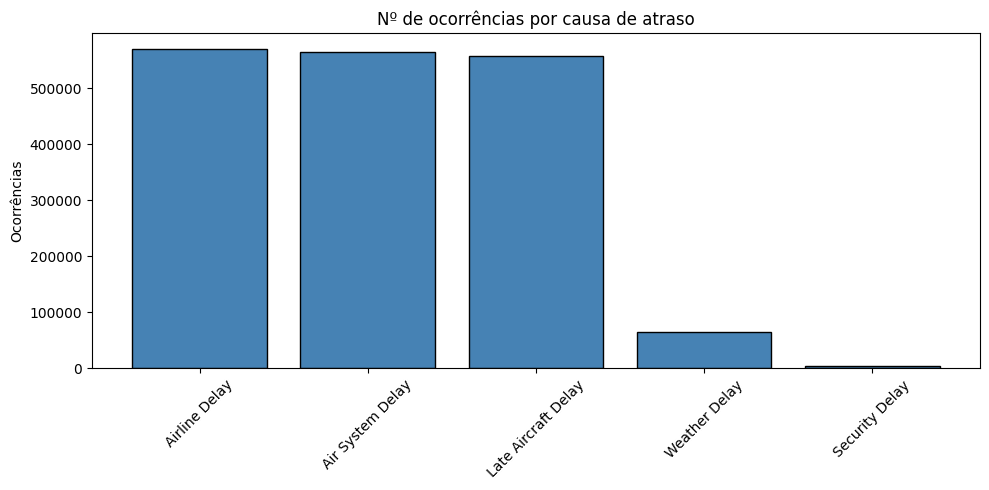

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(causas_df['Causa'], causas_df['Nº Ocorrências'], color='steelblue', edgecolor='black')
ax.set_title('Nº de ocorrências por causa de atraso')
ax.set_ylabel('Ocorrências')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Principais Causas de Atraso Identificados

| Causa | Ocorrencias | Total Minutos | Media (min) |
|-------|-------------|---------------|-------------|
| Airline Delay | 570.022 | 20,17M | 18,97 |
| Air System Delay | 564.826 | 14,34M | 13,48 |
| Late Aircraft Delay | 556.953 | 24,96M | 23,47 |
| Weather Delay | 64.716 | 3,10M | 2,92 |
| Security Delay | 3.484 | 80,99K | 0,08 |

**Insights**:
- As tres principais causas (**Airline, Air System e Late Aircraft**) possuem volume similar de ocorrencias (~560K cada), indicando que sao problemas **sistemicos e recorrentes**, nao pontuais
- **Late Aircraft Delay** e a causa que gera **mais minutos totais de atraso** (quase 25 milhoes de minutos), representando o efeito cascata — quando uma aeronave atrasa, o proximo voo dessa mesma aeronave tambem atrasa
- **Weather Delay** afeta relativamente poucos voos (64,7K), mas e uma variavel **imprevisivel e de dificil controle**
- **Security Delay** e praticamente irrelevante (apenas 3.484 ocorrencias) — a seguranca aeroportuaria nao e um fator significativo de atraso

### Tem algum dia da semana ou horário que costuma ocorrer atrasos?

In [29]:
dias_semana = {1: 'Segunda', 2: 'Terça', 3: 'Quarta', 4: 'Quinta', 5: 'Sexta', 6: 'Sábado', 7: 'Domingo'}
df['dia_semana'] = df['DAY_OF_WEEK'].map(dias_semana)

atraso_dia = df.groupby(['DAY_OF_WEEK', 'dia_semana']).agg(
    media_atraso=('DEPARTURE_DELAY', 'mean'),
    pct_atrasados=('DEPARTURE_DELAY', lambda x: (x > 0).mean() * 100)
).round(2).sort_values('pct_atrasados', ascending=False).reset_index()

display(atraso_dia[['dia_semana', 'media_atraso', 'pct_atrasados']])

,dia_semana,media_atraso,pct_atrasados
0,Quinta,9.96,38.32
1,Sexta,9.43,38.14
2,Segunda,10.87,37.40
3,Domingo,9.40,36.89
4,Quarta,8.65,35.41
5,Terça,9.16,35.02
6,Sábado,7.83,34.00


In [30]:
df['hora_partida'] = df['SCHEDULED_DEPARTURE'] // 100

atraso_hora = df.groupby('hora_partida').agg(
    media_atraso=('DEPARTURE_DELAY', 'mean'),
    pct_atrasados=('DEPARTURE_DELAY', lambda x: (x > 0).mean() * 100),
    total_voos=('DEPARTURE_DELAY', 'count')
).round(2).reset_index()

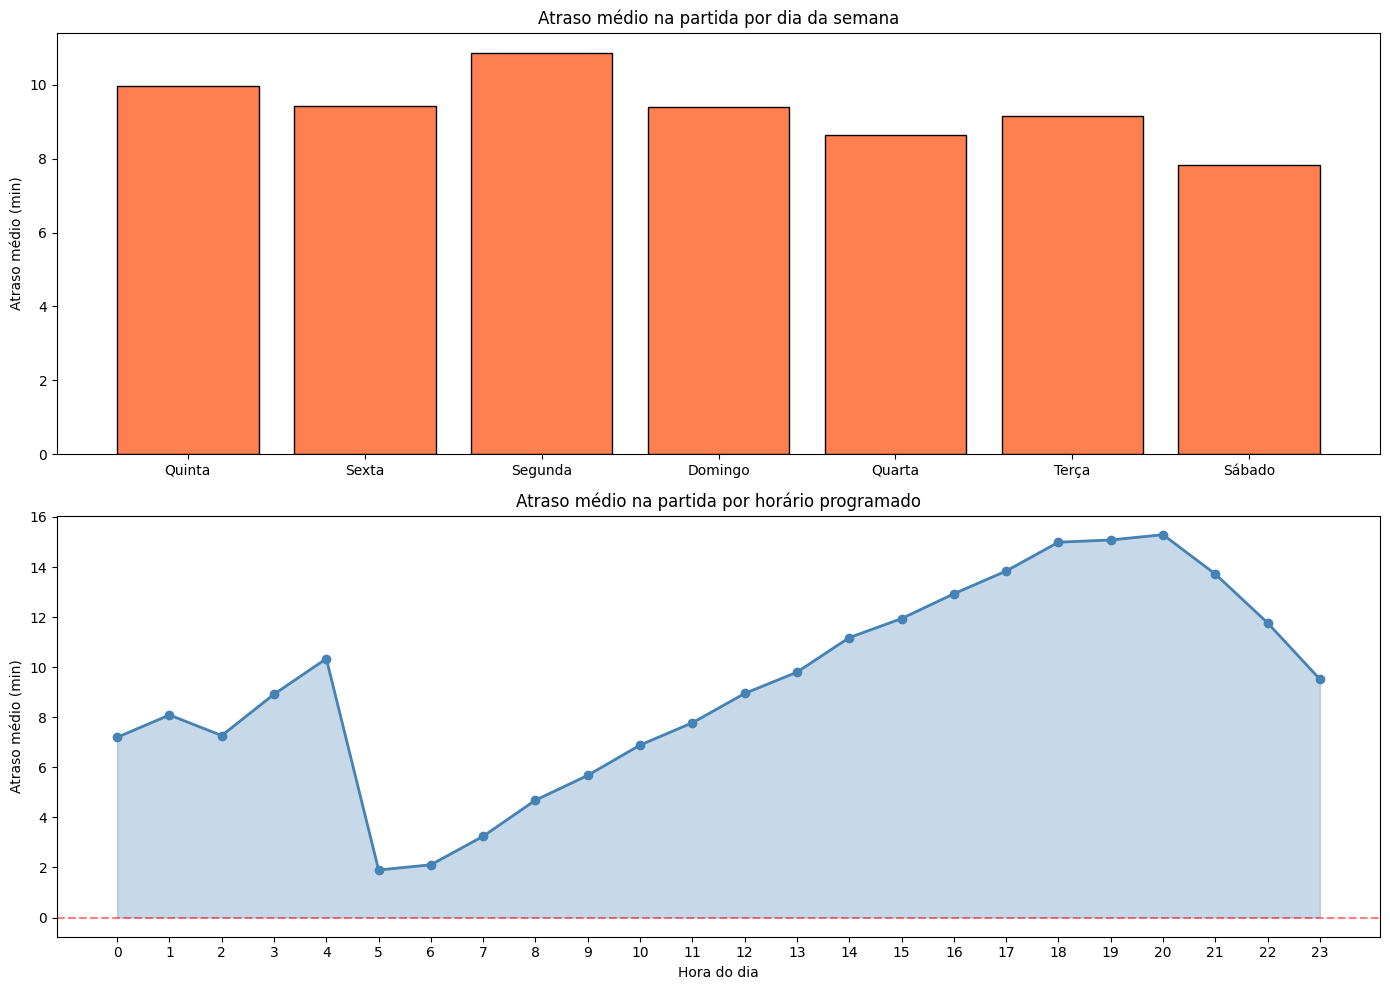

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Dia da semana
axes[0].bar(atraso_dia['dia_semana'], atraso_dia['media_atraso'], color='coral', edgecolor='black')
axes[0].set_title('Atraso médio na partida por dia da semana')
axes[0].set_ylabel('Atraso médio (min)')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Horário
axes[1].plot(atraso_hora['hora_partida'], atraso_hora['media_atraso'], marker='o', color='steelblue', linewidth=2)
axes[1].fill_between(atraso_hora['hora_partida'], atraso_hora['media_atraso'], alpha=0.3, color='steelblue')
axes[1].set_title('Atraso médio na partida por horário programado')
axes[1].set_xlabel('Hora do dia')
axes[1].set_ylabel('Atraso médio (min)')
axes[1].set_xticks(range(0, 24))
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
pior_dia = atraso_dia.loc[atraso_dia['media_atraso'].idxmax(), 'dia_semana']
pior_hora = atraso_hora.loc[atraso_hora['media_atraso'].idxmax(), 'hora_partida']

print(f"Pior dia da semana para atrasos: {pior_dia}")
print(f"Pior horário para atrasos: {int(pior_hora)}h")

Pior dia da semana para atrasos: Segunda
Pior horário para atrasos: 20h


### Padroes Temporais Observados

#### Dia da Semana
| Dia | Media Atraso (min) | % Atrasados |
|-----|-------------------|-------------|
| Segunda | 10,87 | 37,40% |
| Quinta | 9,96 | 38,32% |
| Sexta | 9,43 | 38,14% |
| Domingo | 9,40 | 36,89% |
| Quarta | 8,65 | 35,41% |
| Terca | 9,16 | 35,02% |
| Sabado | 7,83 | 34,00% |

- **Pior dia**: Segunda-feira (media 10,87 min)
- **Melhor dia**: Sabado (media 7,83 min)

#### Horario
- **Pior horario**: 20h (noite)

**Insights**:
- **Segundas-feiras** sao o dia mais problematico, possivelmente por acumulo de atrasos do fim de semana e alto volume de viagens corporativas
- **Sabados** sao os melhores dias, com menor volume de voos e menos pressao operacional
- O **horario noturno (20h)** concentra os piores atrasos devido ao **efeito cascata acumulado ao longo do dia** — atrasos matinais se propagam e amplificam ate a noite
- O padrao temporal sugere que **voos pela manha cedo** tendem a ser mais pontuais, pois as aeronaves estao "resetadas" e ainda nao ha acumulo de atrasos

### Conclusão

#### Principais Descobertas:
1. **36-37% dos voos atrasam**, impactando mais de milhares de passageiros
2. A maioria dos atrasos é **moderada** (mediana de 14-15 min), mas possui uma cauda longa
3. O efeito cascata (**Late Aircraft**) é a maior fonte de minutos perdidos no sistema
4. Padroes temporais sao claros: **segundas e noites** são os periodos mais criticos
5. Companhias apresentam desempenho **muito heterogeneo**

#### Proximos Passos do Projeto:
- Construcao de **features de engenharia** baseadas nessas descobertas (periodo do dia, dia da semana, volume de voos, rota)
- Modelagem preditiva de atrasos usando **classificacao binaria** (atraso >= threshold)
- O conhecimento de que atrasos de partida e chegada estao altamente correlacionados pode orientar a escolha do **target principal** da modelagem

In [33]:
df.to_csv('dados/df_final.csv', index=False)